In [1]:
!pip install nibabel


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: optuna in .\anaconda3\Lib\site-packages (4.9.0)




[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial import ConvexHull, distance_matrix
from scipy.ndimage import distance_transform_edt
from skimage.measure import marching_cubes, mesh_surface_area

# Suppress warnings to maintain a clean execution output
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. Configuration: File Paths & Global Class Label Mapping
# Classes: NOR: 0 (Normal), MINF: 1 (Myocardial Infarction), 
#          DCM: 2 (Dilated Cardiomyopathy), HCM: 3 (Hypertrophic Cardiomyopathy), 
#          ARV/RV: 4 (Abnormal Right Ventricle)
# ==============================================================================
TRAIN_DIR = r"D:\ACDC\ACDC\database\training"
TEST_DIR = r"D:\ACDC\ACDC\database\testing"

DIAGNOSIS_MAP = {
    'NOR': 0, 'MINF': 1, 'DCM': 2, 'HCM': 3, 'ARV': 4, 'RV': 4
}
INV_DIAGNOSIS_MAP = {0: 'NOR', 1: 'MINF', 2: 'DCM', 3: 'HCM', 4: 'RV'}

def parse_cfg_file(cfg_path):
    """
    Parses the patient Info.cfg metadata file.
    
    Args:
        cfg_path (str): Absolute path to the Info.cfg file.
        
    Returns:
        dict: Parsed key-value pairs (e.g., ED/ES frame numbers, clinical group).
    """
    info = {}
    with open(cfg_path, 'r', encoding='utf-8') as f:
        for line in f:
            if ':' in line:
                k, v = line.strip().split(':', 1)
                info[k.strip()] = v.strip()
    return info

def get_max_distance_from_coords(coords, spacing):
    """
    Computes the maximum Euclidean distance (in mm) within a coordinate point set
    scaled by physical voxel spacing, accelerated via Convex Hull.
    """
    if len(coords) < 2:
        return 0.0
    
    # Transform discrete voxel grid indices to patient physical coordinates (mm)
    phys_coords = coords * np.array(spacing)
    if len(phys_coords) <= 3:
        return float(np.max(distance_matrix(phys_coords, phys_coords)))
    
    try:
        # The maximum distance in any point cloud must lie between two Convex Hull vertices
        hull = ConvexHull(phys_coords)
        hull_pts = phys_coords[hull.vertices]
        return float(np.max(distance_matrix(hull_pts, hull_pts)))
    except Exception:
        # Fallback to pairwise distance calculation if convex hull construction degenerates
        return float(np.max(distance_matrix(phys_coords, phys_coords)))

def compute_ibsi_diameters(mask_binary, spacing, prefix=""):
    """
    Computes standard Image Biomarker Standardisation Initiative (IBSI) geometric
    extreme diameters across 3D space and major anatomical projection planes.
    """
    voxels = np.argwhere(mask_binary)
    if len(voxels) == 0:
        return {
            f'{prefix}_max3dDiameter': 0.0,
            f'{prefix}_max2dDiameterAxial': 0.0,
            f'{prefix}_max2dDiameterSagittal': 0.0,
            f'{prefix}_max2dDiameterCoronal': 0.0
        }

    # 1. Full 3D maximum diameter
    max3d = get_max_distance_from_coords(voxels, spacing)

    # 2. Maximum axial/in-plane diameter across short-axis slices (Z-axis)
    max2d_axial = 0.0
    for z in np.unique(voxels[:, 2]):
        slice_pts = voxels[voxels[:, 2] == z][:, :2]
        d = get_max_distance_from_coords(slice_pts, spacing[:2])
        if d > max2d_axial:
            max2d_axial = d

    # 3. Maximum sagittal diameter across X-axis cuts (Y-Z plane)
    max2d_sagittal = 0.0
    for x in np.unique(voxels[:, 0]):
        slice_pts = voxels[voxels[:, 0] == x][:, 1:]
        d = get_max_distance_from_coords(slice_pts, (spacing[1], spacing[2]))
        if d > max2d_sagittal:
            max2d_sagittal = d

    # 4. Maximum coronal diameter across Y-axis cuts (X-Z plane)
    max2d_coronal = 0.0
    for y in np.unique(voxels[:, 1]):
        slice_pts = voxels[voxels[:, 1] == y][:, [0, 2]]
        d = get_max_distance_from_coords(slice_pts, (spacing[0], spacing[2]))
        if d > max2d_coronal:
            max2d_coronal = d

    return {
        f'{prefix}_max3dDiameter': max3d,
        f'{prefix}_max2dDiameterAxial': max2d_axial,
        f'{prefix}_max2dDiameterSagittal': max2d_sagittal,
        f'{prefix}_max2dDiameterCoronal': max2d_coronal
    }

def compute_morphology_features(mask_binary, spacing, prefix=""):
    """
    Calculates IBSI-compliant 3D morphological and topological features
    (e.g., surface area, sphericity, compactness, elongation, volume densities).
    """
    voxels = np.argwhere(mask_binary)
    if len(voxels) < 4:
        return {
            f'{prefix}_SurfaceArea': 0.0, f'{prefix}_Sphericity': 0.0,
            f'{prefix}_Elongation': 0.0, f'{prefix}_Flatness': 0.0,
            f'{prefix}_Solidity': 0.0, f'{prefix}_Compactness1': 0.0,
            f'{prefix}_Compactness2': 0.0, f'{prefix}_SphericalDisproportion': 0.0,
            f'{prefix}_SAVR': 0.0, f'{prefix}_VolumeDensityAABB': 0.0,
            f'{prefix}_VolumeDensityAEE': 0.0, f'{prefix}_max2dAreaAxial': 0.0
        }

    phys_pts = voxels * np.array(spacing)
    v_mm3 = len(voxels) * (spacing[0] * spacing[1] * spacing[2])

    # 1. Surface area reconstruction via Marching Cubes
    try:
        verts, faces, _, _ = marching_cubes(mask_binary.astype(np.uint8), level=0.5, spacing=spacing)
        area_mm2 = mesh_surface_area(verts, faces)
    except Exception:
        area_mm2 = 1.0

    # 2. Sphericity, Compactness, and Surface-to-Volume Ratio (SAVR)
    psi = (np.pi ** (1.0 / 3.0) * (6.0 * v_mm3) ** (2.0 / 3.0)) / (area_mm2 + 1e-6)
    sphericity = float(np.clip(psi, 0.0, 1.0))
    spherical_disp = float(area_mm2 / ((36.0 * np.pi * (v_mm3 ** 2)) ** (1.0 / 3.0) + 1e-6))
    compactness1 = float(v_mm3 / (np.sqrt(np.pi) * (area_mm2 ** 1.5) + 1e-6))
    compactness2 = float(36.0 * np.pi * (v_mm3 ** 2) / ((area_mm2 ** 3) + 1e-6))
    savr = float(area_mm2 / (v_mm3 + 1e-6))

    # 3. PCA-based structural decomposition (Elongation and Flatness)
    cov_mat = np.cov(phys_pts, rowvar=False)
    eigenvals = np.sort(np.linalg.eigvalsh(cov_mat))[::-1]
    l1, l2, l3 = np.maximum(eigenvals, 1e-6)
    elongation = float(np.sqrt(l2 / l1))
    flatness = float(np.sqrt(l3 / l1))

    # 4. Approximate Enclosing Ellipsoid (AEE) volume density
    a, b, c = np.sqrt(l1), np.sqrt(l2), np.sqrt(l3)
    ellipsoid_vol = (4.0 / 3.0) * np.pi * a * b * c
    vol_density_aee = float(np.clip(v_mm3 / (ellipsoid_vol + 1e-6), 0.0, 1.0))

    # 5. Axis-Aligned Bounding Box (AABB) volume density
    bbox_min = np.min(phys_pts, axis=0)
    bbox_max = np.max(phys_pts, axis=0)
    bbox_vol = np.prod(np.maximum(bbox_max - bbox_min, 1e-6))
    vol_density_aabb = float(np.clip(v_mm3 / (bbox_vol + 1e-6), 0.0, 1.0))

    # 6. Convex Hull Solidity
    try:
        hull = ConvexHull(phys_pts)
        solidity = float(np.clip(v_mm3 / (hull.volume + 1e-6), 0.0, 1.0))
    except Exception:
        solidity = 1.0

    # 7. Maximum short-axis cross-sectional 2D area
    slice_voxel_area = spacing[0] * spacing[1]
    max_2d_area = max([np.sum(voxels[:, 2] == z) * slice_voxel_area for z in np.unique(voxels[:, 2])], default=0.0)

    return {
        f'{prefix}_SurfaceArea': float(area_mm2),
        f'{prefix}_Sphericity': sphericity,
        f'{prefix}_SphericalDisproportion': spherical_disp,
        f'{prefix}_Compactness1': compactness1,
        f'{prefix}_Compactness2': compactness2,
        f'{prefix}_SAVR': savr,
        f'{prefix}_Elongation': elongation,
        f'{prefix}_Flatness': flatness,
        f'{prefix}_Solidity': solidity,
        f'{prefix}_VolumeDensityAABB': vol_density_aabb,
        f'{prefix}_VolumeDensityAEE': vol_density_aee,
        f'{prefix}_max2dAreaAxial': float(max_2d_area)
    }

def compute_myocardial_thickness(myo_mask, spacing):
    """
    Estimates physical myocardial wall thickness (in mm) via Euclidean Distance Transform (EDT).
    """
    if np.sum(myo_mask) == 0:
        return {'MYO_Max_Thickness': 0.0, 'MYO_Mean_Thickness': 0.0}
    dist_map = distance_transform_edt(myo_mask, sampling=spacing)
    inner_dists = dist_map[myo_mask > 0]
    return {
        'MYO_Max_Thickness': float(np.percentile(inner_dists, 99) * 2.0),
        'MYO_Mean_Thickness': float(np.mean(inner_dists) * 2.0)
    }

def extract_features_from_dir(patient_dir):
    """
    Extracts clinical volumes, dynamics, IBSI morphology, and BSA-indexed metrics
    from a single patient directory.
    """
    patient_id = os.path.basename(patient_dir)
    cfg_path = os.path.join(patient_dir, 'Info.cfg')
    if not os.path.exists(cfg_path):
        return None

    info = parse_cfg_file(cfg_path)
    group = info.get('Group', '').strip().upper()
    label = DIAGNOSIS_MAP.get(group, -1)

    ed_frame = int(info['ED'])
    es_frame = int(info['ES'])

    # Locate Ground-Truth (GT) segmentation masks
    ed_gt_path = os.path.join(patient_dir, f"{patient_id}_frame{ed_frame:02d}_gt.nii.gz")
    es_gt_path = os.path.join(patient_dir, f"{patient_id}_frame{es_frame:02d}_gt.nii.gz")
    if not os.path.exists(ed_gt_path):
        ed_gt_path = os.path.join(patient_dir, f"{patient_id}_frame{ed_frame:02d}.nii.gz")
    if not os.path.exists(es_gt_path):
        es_gt_path = os.path.join(patient_dir, f"{patient_id}_frame{es_frame:02d}.nii.gz")

    if not (os.path.exists(ed_gt_path) and os.path.exists(es_gt_path)):
        return None

    ed_nii = nib.load(ed_gt_path)
    es_nii = nib.load(es_gt_path)
    ed_mask = ed_nii.get_fdata()
    es_mask = es_nii.get_fdata()

    # Voxel volume conversion: 1 mm^3 = 0.001 mL
    zooms = ed_nii.header.get_zooms()[:3]
    voxel_vol_ml = (zooms[0] * zooms[1] * zooms[2]) / 1000.0

    # Absolute chamber volumes (Label 1: RV, Label 2: MYO, Label 3: LV)
    lvedv = float(np.sum(ed_mask == 3) * voxel_vol_ml)
    lvesv = float(np.sum(es_mask == 3) * voxel_vol_ml)
    rvedv = float(np.sum(ed_mask == 1) * voxel_vol_ml)
    rvesv = float(np.sum(es_mask == 1) * voxel_vol_ml)
    
    # Myocardial mass computation incorporating standard density factor (1.05 g/mL)
    MYO_DENSITY = 1.05
    myo_ed = float(np.sum(ed_mask == 2) * voxel_vol_ml * MYO_DENSITY)
    myo_es = float(np.sum(es_mask == 2) * voxel_vol_ml * MYO_DENSITY)

    # Functional metrics and clinical anatomical ratios
    lvef = float((lvedv - lvesv) / (lvedv + 1e-6))
    rvef = float((rvedv - rvesv) / (rvedv + 1e-6))
    myo_ratio = float(myo_es / (myo_ed + 1e-6))

    myo_lv_ratio_ed = float(myo_ed / (lvedv + 1e-6))
    rv_lv_ratio_ed = float(rvedv / (lvedv + 1e-6))

    # Radiomic geometric and morphological descriptors
    lv_diameters = compute_ibsi_diameters(ed_mask == 3, zooms, prefix='LV')
    rv_diameters = compute_ibsi_diameters(ed_mask == 1, zooms, prefix='RV')
    lv_shape = compute_morphology_features(ed_mask == 3, zooms, prefix='LV')
    rv_shape = compute_morphology_features(ed_mask == 1, zooms, prefix='RV')
    myo_thickness = compute_myocardial_thickness(ed_mask == 2, zooms)

    # Body Surface Area (BSA) normalization via Mosteller formula
    height = float(info.get('Height', 0))
    weight = float(info.get('Weight', 0))
    bsa = float(np.sqrt((height * weight) / 3600.0) if (height > 0 and weight > 0) else 1.0)

    record = {
        'patient': patient_id, 'label': label, 'group': group,
        'LVEDV': lvedv, 'LVESV': lvesv, 'LVEF': lvef,
        'RVEDV': rvedv, 'RVESV': rvesv, 'RVEF': rvef,
        'MYO_ED': myo_ed, 'MYO_ES': myo_es, 'MYO_Ratio': myo_ratio,
        'MYO_LV_Ratio_ED': myo_lv_ratio_ed,
        'RV_LV_Ratio_ED': rv_lv_ratio_ed,
        'LVEDVi': lvedv / bsa,
        'RVEDVi': rvedv / bsa,
        'MYO_EDi': myo_ed / bsa,
        'Height': height, 'Weight': weight, 'BSA': bsa
    }
    record.update(lv_diameters)
    record.update(rv_diameters)
    record.update(lv_shape)
    record.update(rv_shape)
    record.update(myo_thickness)
    return record

print("Cell 1 executed: Primitive operators and feature extraction functions are ready.")

Cell 1 executed: Primitive operators and feature extraction functions are ready.


In [4]:
print("Starting batch feature extraction on the training cohort...")
train_patient_dirs = sorted(glob.glob(os.path.join(TRAIN_DIR, "patient*")))
train_records = [extract_features_from_dir(p) for p in train_patient_dirs]
df_train = pd.DataFrame([r for r in train_records if r is not None])

# Exclude metadata columns to construct the feature matrix
feature_cols = [c for c in df_train.columns if c not in ['patient', 'label', 'group']]
X_train_all = df_train[feature_cols].values
y_train = df_train['label'].values

print(f"Extraction complete: {len(df_train)} samples, {len(feature_cols)} feature dimensions.")
df_train.to_csv('df_train_all_51_features.csv', index=False)
print("Full training feature matrix persisted to: df_train_all_51_features.csv")

Starting batch feature extraction on the training cohort...
Extraction complete: 100 samples, 51 feature dimensions.
Full training feature matrix persisted to: df_train_all_51_features.csv


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

TARGET_N_FEATURES = 15
base_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
cv_3fold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 1. Benchmark: Full 51-feature baseline cross-validation score (3-Fold)
score_all_raw = cross_val_score(base_rf, X_train_all, y_train, cv=cv_3fold, scoring='accuracy').mean()

# 2. Leakage-Free Cross-Validation Pipeline (3-Fold)
# Ensures RFE feature selection is computed strictly within training folds, preventing validation data leakage
rfe_pipeline = Pipeline([
    ('rfe', RFE(estimator=base_rf, n_features_to_select=TARGET_N_FEATURES, step=1)),
    ('classifier', base_rf)
])
score_leak_free = cross_val_score(rfe_pipeline, X_train_all, y_train, cv=cv_3fold, scoring='accuracy').mean()

print("=" * 60)
print("Stratified 3-Fold Cross-Validation Accuracy Comparison:")
print(f" - Full Feature Set ({len(feature_cols)} features): {score_all_raw * 100:.2f}%")
print(f" - Leakage-Free RFE Pipeline ({TARGET_N_FEATURES} features): {score_leak_free * 100:.2f}%")
print("=" * 60)

# 3. Fit RFE on the full training cohort to export the final Top 15 subset
rfe_full = RFE(estimator=base_rf, n_features_to_select=TARGET_N_FEATURES, step=1)
rfe_full.fit(X_train_all, y_train)

feature_ranking_df = pd.DataFrame({
    'Feature': feature_cols,
    'Selected': rfe_full.support_,
    'RFE_Rank': rfe_full.ranking_
}).sort_values(by='RFE_Rank', ascending=True).reset_index(drop=True)

selected_features_15 = feature_ranking_df.loc[feature_ranking_df['Selected'], 'Feature'].tolist()

print(f"\nSuccessfully locked Top {TARGET_N_FEATURES} core features:")
for i, f_name in enumerate(selected_features_15, 1):
    print(f"  {i:02d}. {f_name}")

feature_ranking_df.to_csv('rfe_feature_ranking.csv', index=False)
df_train[['patient', 'group', 'label'] + selected_features_15].to_csv('df_train_selected_top15.csv', index=False)
print("\nFeature ranking table and Top 15 feature subsets have been persisted.")

Stratified 3-Fold Cross-Validation Accuracy Comparison:
 - Full Feature Set (51 features): 92.99%
 - Leakage-Free RFE Pipeline (15 features): 91.00%

Successfully locked Top 15 core features:
  01. LVEDV
  02. LVESV
  03. LVEF
  04. RVESV
  05. MYO_ED
  06. RVEF
  07. MYO_ES
  08. MYO_LV_Ratio_ED
  09. LVEDVi
  10. RV_LV_Ratio_ED
  11. RVEDVi
  12. LV_SAVR
  13. MYO_Max_Thickness
  14. MYO_Mean_Thickness
  15. LV_max2dAreaAxial

Feature ranking table and Top 15 feature subsets have been persisted.


In [6]:
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier

# Suppress Optuna trial logging for cleaner console output
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_train_15 = df_train[selected_features_15].values
y_train = df_train['label'].values
cv_3fold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 1. Define model architectures and hyperparameter search spaces
def create_model(trial, classifier_name):
    if classifier_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=trial.suggest_int('rf_n_estimators', 50, 300, step=50),
            max_depth=trial.suggest_int('rf_max_depth', 2, 8),
            min_samples_split=trial.suggest_int('rf_min_samples_split', 2, 8),
            min_samples_leaf=trial.suggest_int('rf_min_samples_leaf', 1, 4),
            max_features=trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None]),
            random_state=42
        )
    elif classifier_name == "Extra Trees":
        return ExtraTreesClassifier(
            n_estimators=trial.suggest_int('et_n_estimators', 50, 300, step=50),
            max_depth=trial.suggest_int('et_max_depth', 2, 8),
            min_samples_split=trial.suggest_int('et_min_samples_split', 2, 8),
            min_samples_leaf=trial.suggest_int('et_min_samples_leaf', 1, 4),
            random_state=42
        )
    elif classifier_name == "XGBoost":
        return XGBClassifier(
            n_estimators=trial.suggest_int('xgb_n_estimators', 50, 200, step=25),
            max_depth=trial.suggest_int('xgb_max_depth', 2, 6),
            learning_rate=trial.suggest_float('xgb_lr', 0.01, 0.2, log=True),
            subsample=trial.suggest_float('xgb_subsample', 0.6, 1.0),
            colsample_bytree=trial.suggest_float('xgb_colsample', 0.6, 1.0),
            random_state=42,
            eval_metric='mlogloss'
        )
    elif classifier_name == "SVM":
        c = trial.suggest_float('svm_c', 0.1, 100.0, log=True)
        kernel = trial.suggest_categorical('svm_kernel', ['linear', 'rbf'])
        gamma = trial.suggest_categorical('svm_gamma', ['scale', 'auto'])
        return Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(C=c, kernel=kernel, gamma=gamma, probability=True, random_state=42))
        ])
    elif classifier_name == "Logistic Regression":
        c = trial.suggest_float('lr_c', 0.01, 10.0, log=True)
        return Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(C=c, max_iter=1000, random_state=42))
        ])
    elif classifier_name == "k-NN":
        n_neighbors = trial.suggest_int('knn_k', 3, 11, step=2)
        weights = trial.suggest_categorical('knn_weights', ['uniform', 'distance'])
        return Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights))
        ])
    elif classifier_name == "MLP":
        hidden = trial.suggest_categorical('mlp_hidden', [(64, 32), (32,), (64,)])
        alpha = trial.suggest_float('mlp_alpha', 1e-4, 1e-1, log=True)
        lr = trial.suggest_float('mlp_lr_init', 1e-3, 1e-1, log=True)
        return Pipeline([
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(hidden_layer_sizes=hidden, alpha=alpha, learning_rate_init=lr, max_iter=800, random_state=42))
        ])
    elif classifier_name == "LDA":
        solver = trial.suggest_categorical('lda_solver', ['svd', 'lsqr'])
        return Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver=solver))
        ])

# 2. Run Bayesian optimization across model candidates
model_candidates = ["Random Forest", "Extra Trees", "XGBoost", "SVM", "Logistic Regression", "k-NN", "LDA", "MLP"]
leaderboard_records = []
best_models_dict = {}

print("Initiating automated Bayesian hyperparameter tuning across 3-fold CV...\n")

for clf_name in model_candidates:
    def objective(trial):
        model = create_model(trial, clf_name)
        scores = cross_val_score(model, X_train_15, y_train, cv=cv_3fold, scoring='accuracy', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=30, timeout=60)

    best_acc = study.best_value
    best_params = study.best_params

    # Refit the optimal configuration across the full dataset and calculate CV dispersion
    best_model = create_model(optuna.trial.FixedTrial(best_params), clf_name)
    best_scores = cross_val_score(best_model, X_train_15, y_train, cv=cv_3fold, scoring='accuracy', n_jobs=-1)
    best_model.fit(X_train_15, y_train)
    best_models_dict[clf_name] = best_model

    leaderboard_records.append({
        'Model Name': clf_name,
        'Mean Accuracy': best_scores.mean(),
        '3-Fold Acc (Mean +- Std)': f"{best_scores.mean() * 100:.2f}% +- {best_scores.std() * 100:.2f}%",
        'Best Hyperparameters': str(best_params)
    })
    print(f"[{clf_name}] Tuning Complete -> 3-Fold CV Accuracy: {best_scores.mean() * 100:.2f}% +- {best_scores.std() * 100:.2f}%")

# 3. Construct and display the leaderboard
df_benchmark = pd.DataFrame(leaderboard_records).sort_values(by='Mean Accuracy', ascending=False).reset_index(drop=True)
print("\n" + "=" * 75)
print("Automated Hyperparameter Tuning Benchmark Leaderboard (3-Fold CV)")
print("=" * 75)
for idx, row in df_benchmark.iterrows():
    print(f"{idx+1}. {row['Model Name']:<22} | {row['3-Fold Acc (Mean +- Std)']}")

champion_model_name = df_benchmark.iloc[0]['Model Name']
print(f"\nOverall Champion Model: [{champion_model_name}]")
champion_model = best_models_dict[champion_model_name]

Initiating automated Bayesian hyperparameter tuning across 3-fold CV...

[Random Forest] Tuning Complete -> 3-Fold CV Accuracy: 94.98% +- 5.16%
[Extra Trees] Tuning Complete -> 3-Fold CV Accuracy: 95.99% +- 3.79%
[XGBoost] Tuning Complete -> 3-Fold CV Accuracy: 92.99% +- 6.24%
[SVM] Tuning Complete -> 3-Fold CV Accuracy: 96.02% +- 1.34%
[Logistic Regression] Tuning Complete -> 3-Fold CV Accuracy: 95.07% +- 4.99%
[k-NN] Tuning Complete -> 3-Fold CV Accuracy: 92.99% +- 1.47%
[LDA] Tuning Complete -> 3-Fold CV Accuracy: 94.03% +- 2.37%
[MLP] Tuning Complete -> 3-Fold CV Accuracy: 97.03% +- 2.40%

Automated Hyperparameter Tuning Benchmark Leaderboard (3-Fold CV)
1. MLP                    | 97.03% +- 2.40%
2. SVM                    | 96.02% +- 1.34%
3. Extra Trees            | 95.99% +- 3.79%
4. Logistic Regression    | 95.07% +- 4.99%
5. Random Forest          | 94.98% +- 5.16%
6. LDA                    | 94.03% +- 2.37%
7. XGBoost                | 92.99% +- 6.24%
8. k-NN                  

Starting inference on the Test Set...
Test set inference complete. Results saved to: acdc_test_predictions_champion.csv

=== Independent Test Set Evaluation Report (Model: MLP) ===
Test Accuracy: 92.00%

Detailed Classification Report:
              precision    recall  f1-score   support

         NOR     1.0000    0.9000    0.9474        10
        MINF     0.8889    0.8000    0.8421        10
         DCM     0.9000    0.9000    0.9000        10
         HCM     0.8333    1.0000    0.9091        10
          RV     1.0000    1.0000    1.0000        10

    accuracy                         0.9200        50
   macro avg     0.9244    0.9200    0.9197        50
weighted avg     0.9244    0.9200    0.9197        50



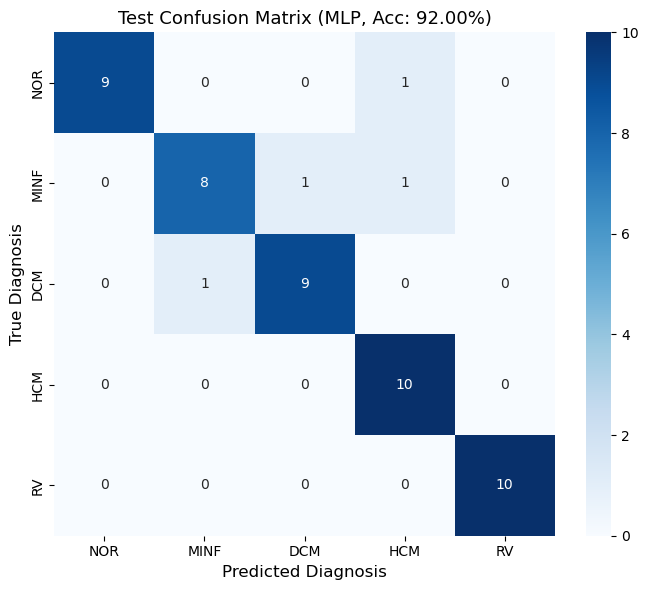

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Starting inference on the Test Set...")
if os.path.exists(TEST_DIR):
    test_patient_dirs = sorted(glob.glob(os.path.join(TEST_DIR, "patient*")))
    test_records = [extract_features_from_dir(p) for p in test_patient_dirs]
    df_test = pd.DataFrame([r for r in test_records if r is not None])

    if len(df_test) > 0:
        # Align features to the optimal Top 15 selected subset
        X_test_15 = df_test[selected_features_15].values
        y_test_pred = champion_model.predict(X_test_15)

        df_test['Pred_Label'] = y_test_pred
        df_test['Pred_Group'] = [INV_DIAGNOSIS_MAP[k] for k in y_test_pred]

        if hasattr(champion_model, "predict_proba"):
            y_test_prob = champion_model.predict_proba(X_test_15)
            df_test['Confidence'] = np.max(y_test_prob, axis=1)

        output_csv = 'acdc_test_predictions_champion.csv'
        cols_to_save = ['patient', 'Pred_Group'] + (['Confidence'] if 'Confidence' in df_test else [])
        df_test[cols_to_save].to_csv(output_csv, index=False)
        print(f"Test set inference complete. Results saved to: {output_csv}")

        # If ground-truth labels are available in test Info.cfg, compute evaluation metrics
        valid_labels = df_test['label'].dropna().unique()
        if (df_test['label'] != -1).all() and len(valid_labels) > 1:
            y_test_true = df_test['label'].values
            test_acc = accuracy_score(y_test_true, y_test_pred)
            target_names = ['NOR', 'MINF', 'DCM', 'HCM', 'RV']

            print("\n" + "=" * 60)
            print(f"=== Independent Test Set Evaluation Report (Model: {champion_model_name}) ===")
            print(f"Test Accuracy: {test_acc * 100:.2f}%")
            print("=" * 60)

            print("\nDetailed Classification Report:")
            print(classification_report(y_test_true, y_test_pred, target_names=target_names, digits=4))

            cm = confusion_matrix(y_test_true, y_test_pred)
            plt.figure(figsize=(7, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=target_names, yticklabels=target_names)
            plt.xlabel('Predicted Diagnosis', fontsize=12)
            plt.ylabel('True Diagnosis', fontsize=12)
            plt.title(f'Test Confusion Matrix ({champion_model_name}, Acc: {test_acc * 100:.2f}%)', fontsize=13)
            plt.tight_layout()
            plt.show()
    else:
        print("No valid test patient instances found.")
else:
    print(f"Test directory not found: {TEST_DIR}. Please check the path configuration.")